# 08 - Toxicity Prediction Tool (GCN Only)

**Interactive prediction using Graph Convolutional Network (GCN)**

## How to Use:
1. Enter your SMILES string in the input cell
2. The notebook validates the molecule
3. Runs GCN predictions for all 12 toxicity endpoints
4. Displays results table with toxicity predictions

In [23]:

import os
import sys
import numpy as np
import pandas as pd
import torch
import warnings
warnings.filterwarnings('ignore')


from rdkit import Chem
from rdkit.Chem import AllChem, Draw
from IPython.display import display, HTML


sys.path.insert(0, os.path.abspath('../src'))


import dgl


CHECKPOINTS_DIR = '../checkpoints'


TOXICITY_ENDPOINTS = [
    'NR-AhR', 'NR-AR', 'NR-AR-LBD', 'NR-Aromatase',
    'NR-ER', 'NR-ER-LBD', 'NR-PPAR-gamma',
    'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53'
]


DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'



In [24]:
# ============================================================================
# SMILES VALIDATION FUNCTION
# ============================================================================
def validate_smiles(smiles):
   
    result = {
        'valid': False,
        'smiles': smiles,
        'molecule': None,
        'num_atoms': 0,
        'molecular_weight': 0,
        'error': None
    }
    
    if not smiles or not isinstance(smiles, str):
        result['error'] = "Empty or invalid input"
        return result
    
    # Clean the SMILES string
    smiles = smiles.strip()
    
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            result['error'] = "Invalid SMILES structure"
            return result
        
        # Get molecule properties
        from rdkit.Chem import Descriptors
        result['valid'] = True
        result['molecule'] = mol
        result['num_atoms'] = mol.GetNumAtoms()
        result['molecular_weight'] = round(Descriptors.MolWt(mol), 2)
        result['canonical_smiles'] = Chem.MolToSmiles(mol)
        
    except Exception as e:
        result['error'] = str(e)
    
    return result

def display_molecule(mol, size=(300, 200)):
    """Display molecule structure."""
    if mol is not None:
        img = Draw.MolToImage(mol, size=size)
        display(img)



In [25]:

ATOM_TYPES = ['C', 'N', 'O', 'S', 'F', 'Si', 'P', 'Cl', 'Br', 'Mg', 'Na', 
              'Ca', 'Fe', 'As', 'Al', 'I', 'B', 'V', 'K', 'Tl', 'Yb', 'Sb', 
              'Sn', 'Ag', 'Pd', 'Co', 'Se', 'Ti', 'Zn', 'H', 'Li', 'Ge', 
              'Cu', 'Au', 'Ni', 'Cd', 'In', 'Mn', 'Zr', 'Cr', 'Pt', 'Hg', 'Pb']

HYBRIDIZATIONS = [
    Chem.rdchem.HybridizationType.SP,
    Chem.rdchem.HybridizationType.SP2,
    Chem.rdchem.HybridizationType.SP3,
    Chem.rdchem.HybridizationType.SP3D,
    Chem.rdchem.HybridizationType.SP3D2
]

FORMAL_CHARGES = [-1, -2, 1, 2, 0]

def get_atom_features(atom):
   
    features = []
    
    # 1. Atom type (one-hot encoding) - 44 dimensions
    atom_type = atom.GetSymbol()
    atom_type_encoding = [0] * 44
    if atom_type in ATOM_TYPES:
        idx = ATOM_TYPES.index(atom_type)
        atom_type_encoding[idx] = 1
    else:
        atom_type_encoding[-1] = 1  # Unknown atom type
    features.extend(atom_type_encoding)
    
    # 2. Degree (one-hot encoding) - 11 dimensions
    degree = atom.GetDegree()
    degree_encoding = [0] * 11
    if degree < 11:
        degree_encoding[degree] = 1
    else:
        degree_encoding[-1] = 1
    features.extend(degree_encoding)
    
    # 3. Formal charge (one-hot encoding) - 5 dimensions
    formal_charge = atom.GetFormalCharge()
    charge_encoding = [0] * 5
    if formal_charge in FORMAL_CHARGES:
        idx = FORMAL_CHARGES.index(formal_charge)
        charge_encoding[idx] = 1
    features.extend(charge_encoding)
    
    # 4. Number of hydrogens (one-hot encoding) - 5 dimensions
    num_hs = atom.GetTotalNumHs()
    hs_encoding = [0] * 5
    if num_hs < 5:
        hs_encoding[num_hs] = 1
    else:
        hs_encoding[-1] = 1
    features.extend(hs_encoding)
    
    # 5. Hybridization (one-hot encoding) - 5 dimensions
    hybridization = atom.GetHybridization()
    hybrid_encoding = [0] * 5
    if hybridization in HYBRIDIZATIONS:
        idx = HYBRIDIZATIONS.index(hybridization)
        hybrid_encoding[idx] = 1
    features.extend(hybrid_encoding)
    
    # 6. Is aromatic (binary) - 1 dimension
    features.append(int(atom.GetIsAromatic()))
    
    # 7. Is in ring (binary) - 1 dimension
    features.append(int(atom.IsInRing()))
    
    # 8. Chirality (2 features) - 2 dimensions
    chirality = atom.GetChiralTag()
    features.append(int(chirality == Chem.rdchem.ChiralType.CHI_TETRAHEDRAL_CW or 
                       chirality == Chem.rdchem.ChiralType.CHI_TETRAHEDRAL_CCW))
    features.append(int(chirality == Chem.rdchem.ChiralType.CHI_OTHER))
    
    return features  # Total: 74 features


def smiles_to_graph(smiles):
    
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    
    num_atoms = mol.GetNumAtoms()
    
    # Get atom features
    atom_features = []
    for atom in mol.GetAtoms():
        atom_features.append(get_atom_features(atom))
    
    atom_features = torch.tensor(atom_features, dtype=torch.float32)
    
    # Get bonds (edges)
    src_nodes = []
    dst_nodes = []
    
    for bond in mol.GetBonds():
        start = bond.GetBeginAtomIdx()
        end = bond.GetEndAtomIdx()
        # Add both directions (undirected graph)
        src_nodes.extend([start, end])
        dst_nodes.extend([end, start])
    
    # Handle molecules with no bonds
    if len(src_nodes) == 0:
        src_nodes = [0]
        dst_nodes = [0]
    
    # Create DGL graph
    graph = dgl.graph((src_nodes, dst_nodes), num_nodes=num_atoms)
    # Use 'feat' key to match training code
    graph.ndata['feat'] = atom_features
    
    return graph



In [ ]:

import torch.nn as nn
import torch.nn.functional as F
from dgl.nn.pytorch import GraphConv
from dgl.nn.pytorch.glob import AvgPooling, MaxPooling
from pathlib import Path

# Path setup
CHECKPOINT_PATH = Path(CHECKPOINTS_DIR)
ENDPOINTS = TOXICITY_ENDPOINTS


class GCNEncoder(nn.Module):

    
    def __init__(self, in_feats, hidden_feats, num_layers=3, dropout=0.2, activation=F.relu):
        super(GCNEncoder, self).__init__()
        
        self.num_layers = num_layers
        self.dropout = dropout
        self.activation = activation
        
        # Build graph convolutional layers
        self.conv_layers = nn.ModuleList()
        self.dropout_layers = nn.ModuleList()
        
        # First layer
        self.conv_layers.append(GraphConv(in_feats, hidden_feats[0]))
        self.dropout_layers.append(nn.Dropout(dropout))
        
        # Hidden layers
        for i in range(1, num_layers):
            in_dim = hidden_feats[i-1]
            out_dim = hidden_feats[i] if i < len(hidden_feats) else hidden_feats[-1]
            self.conv_layers.append(GraphConv(in_dim, out_dim))
            self.dropout_layers.append(nn.Dropout(dropout))
        
        # Pooling layers
        self.max_pool = MaxPooling()
        self.avg_pool = AvgPooling()
        self.pool_weight = nn.Parameter(torch.tensor([0.5, 0.5]))
        
    def forward(self, g, features):
        h = features
        for i in range(self.num_layers):
            h = self.conv_layers[i](g, h)
            h = self.activation(h)
            h = self.dropout_layers[i](h)
        
        g.ndata['h'] = h
        max_pooled = self.max_pool(g, h)
        avg_pooled = self.avg_pool(g, h)
        
        weights = F.softmax(self.pool_weight, dim=0)
        graph_representation = weights[0] * max_pooled + weights[1] * avg_pooled
        
        return graph_representation


class MLPClassifier(nn.Module):
    """MLP Classifier (matches src/model.py)"""
    
    def __init__(self, in_feats, hidden_feats, num_classes=2, dropout=0.2):
        super(MLPClassifier, self).__init__()
        self.fc1 = nn.Linear(in_feats, hidden_feats)
        self.bn1 = nn.BatchNorm1d(hidden_feats)
        self.dropout1 = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden_feats, num_classes)
        
    def forward(self, x):
        x = self.fc1(x)
        if self.training and x.size(0) > 1:
            x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout1(x)
        x = self.fc2(x)
        return x


class GCNModel(nn.Module):
    """Complete GCN Model (matches src/model.py)"""
    
    def __init__(self, in_feats, hidden_feats, num_layers=3, 
                 classifier_hidden=128, num_classes=2, dropout=0.2):
        super(GCNModel, self).__init__()
        
        self.encoder = GCNEncoder(
            in_feats=in_feats,
            hidden_feats=hidden_feats,
            num_layers=num_layers,
            dropout=dropout
        )
        
        encoder_output_dim = hidden_feats[-1]
        self.classifier = MLPClassifier(
            in_feats=encoder_output_dim,
            hidden_feats=classifier_hidden,
            num_classes=num_classes,
            dropout=dropout
        )
        
    def forward(self, g, features):
        graph_representation = self.encoder(g, features)
        predictions = self.classifier(graph_representation)
        return predictions


def load_gcn_model(endpoint, in_feats=74, hidden_dims=[64, 128, 256], 
                   num_layers=3, classifier_hidden=128):
    """Load trained GCN model for an endpoint."""
    model_path = CHECKPOINT_PATH / endpoint / 'best_model.pt'
    
    if not model_path.exists():
        return None, f"Model not found at {model_path}"
    
    try:
        model = GCNModel(
            in_feats=in_feats,  # 74 features to match training
            hidden_feats=hidden_dims,
            num_layers=num_layers,
            classifier_hidden=classifier_hidden,
            num_classes=2,
            dropout=0.2
        )
        
        # Load checkpoint
        checkpoint = torch.load(model_path, map_location=DEVICE)
        
        # Handle both formats: direct state_dict or nested in checkpoint dict
        if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
            model.load_state_dict(checkpoint['model_state_dict'])
        else:
            model.load_state_dict(checkpoint)
            
        model.to(DEVICE)
        model.eval()
        return model, None
    except Exception as e:
        return None, str(e)


✓ GCN model classes defined (74-dim input features)


In [28]:
#
from pathlib import Path

CHECKPOINT_PATH = Path(CHECKPOINTS_DIR)
ENDPOINTS = TOXICITY_ENDPOINTS

def get_available_endpoints():
    """Get list of endpoints with trained GCN models."""
    available = []
    for endpoint in ENDPOINTS:
        gcn_path = CHECKPOINT_PATH / endpoint / 'best_model.pt'
        if gcn_path.exists():
            available.append(endpoint)
    return available

# Check available models
available_endpoints = get_available_endpoints()



## 🔬 Enter Your SMILES for Prediction

Run the cell below to input your SMILES string and get GCN toxicity predictions.

SMILES VALIDATION
✓ Valid SMILES: CC(=O)Oc1ccccc1C(=O)O
  Atoms: 13
  Molecular Weight: 180.16 g/mol

Molecule Structure:


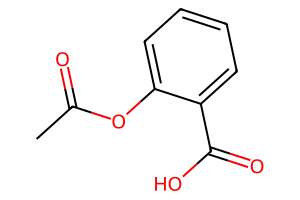

In [29]:

#USER_SMILES = "CC(=O)OC1=CC=CC=C1C(=O)O"  # Example: Aspirin


USER_SMILES = input("Enter SMILES string: ")


print("=" * 60)
print("SMILES VALIDATION")
print("=" * 60)

validation = validate_smiles(USER_SMILES)

if validation['valid']:
    print(f"✓ Valid SMILES: {validation['canonical_smiles']}")
    print(f"  Atoms: {validation['num_atoms']}")
    print(f"  Molecular Weight: {validation['molecular_weight']} g/mol")
    print("\nMolecule Structure:")
    display_molecule(validation['molecule'])
else:
    print(f"✗ Invalid SMILES: {validation['error']}")
    print("Please enter a valid SMILES string and run this cell again.")

## 📊 Run GCN Predictions

The cell below runs GCN predictions for all 12 toxicity endpoints.

In [30]:


def predict_with_gcn(smiles, endpoint):
    
    result = {'endpoint': endpoint, 'prediction': None, 'probability': None, 'status': 'error'}
    
    # Load model
    model, error = load_gcn_model(endpoint)
    if model is None:
        result['status'] = f'Model error: {error}'
        return result
    
    # Convert to graph
    graph = smiles_to_graph(smiles)
    if graph is None:
        result['status'] = 'Graph conversion failed'
        return result
    
    try:
        # Move graph to device
        graph = graph.to(DEVICE)
        features = graph.ndata['feat'].float().to(DEVICE)
        
        # Predict
        with torch.no_grad():
            logits = model(graph, features)
            probs = F.softmax(logits, dim=1)
            pred = torch.argmax(probs, dim=1).item()
            prob = probs[0, 1].item()  # Probability of toxic class
        
        result['prediction'] = 'Toxic' if pred == 1 else 'Non-toxic'
        result['probability'] = round(prob * 100, 2)
        result['status'] = 'success'
        
    except Exception as e:
        result['status'] = str(e)
    
    return result



In [34]:


if validation['valid']:
    print("=" * 70)
    print(f"GCN TOXICITY PREDICTIONS FOR: {validation['canonical_smiles']}")
    print("=" * 70)
    
    all_results = []
    
    for endpoint in ENDPOINTS:
        print(f"📍 Processing {endpoint}...", end=" ")
        result = predict_with_gcn(USER_SMILES, endpoint)
        all_results.append(result)
        
        if result['status'] == 'success':
            print(f"✓ {result['prediction']} ({result['probability']}%)")
        else:
            print(f"✗ {result['status']}")
    
    results_df = pd.DataFrame(all_results)
    
else:
    print("⚠️ Please enter a valid SMILES string first.")

GCN TOXICITY PREDICTIONS FOR: CC(=O)Oc1ccccc1C(=O)O
📍 Processing NR-AhR... ✓ Non-toxic (49.17%)
📍 Processing NR-AR... ✓ Toxic (50.05%)
📍 Processing NR-AR-LBD... ✓ Non-toxic (35.63%)
📍 Processing NR-Aromatase... ✓ Toxic (72.59%)
📍 Processing NR-ER... ✓ Toxic (53.63%)
📍 Processing NR-ER-LBD... ✓ Toxic (73.64%)
📍 Processing NR-PPAR-gamma... ✓ Non-toxic (39.1%)
📍 Processing SR-ARE... ✓ Toxic (64.6%)
📍 Processing SR-ATAD5... ✓ Non-toxic (0.01%)
📍 Processing SR-HSE... ✓ Toxic (68.68%)
📍 Processing SR-MMP... ✓ Toxic (78.17%)
📍 Processing SR-p53... ✓ Toxic (78.67%)


## 📋 Results Table

View the GCN prediction results for all toxicity endpoints.

In [35]:


if validation['valid'] and len(all_results) > 0:
    print("\n" + "=" * 70)
    print("GCN PREDICTION RESULTS")
    print("=" * 70)
    
    # Create clean display dataframe
    display_df = results_df[results_df['status'] == 'success'][['endpoint', 'prediction', 'probability']].copy()
    display_df.columns = ['Endpoint', 'Prediction', 'Toxic Probability (%)']
    
    # Display table
    display(display_df)
    
    # Summary
    toxic_count = (display_df['Prediction'] == 'Toxic').sum()
    total = len(display_df)
    
    print(f"\n📊 SUMMARY:")
    print(f"   🔴 Toxic: {toxic_count}/{total} endpoints")
    print(f"   🟢 Non-toxic: {total - toxic_count}/{total} endpoints")
    
    # High risk endpoints
    high_risk = display_df[display_df['Toxic Probability (%)'] > 50]['Endpoint'].tolist()
    if high_risk:
        print(f"\n⚠️  HIGH RISK ENDPOINTS (>50% probability):")
        for ep in high_risk:
            prob = display_df[display_df['Endpoint'] == ep]['Toxic Probability (%)'].values[0]
            print(f"   - {ep}: {prob}%")
else:
    print("⚠️ No results to display. Please run the prediction cells first.")


GCN PREDICTION RESULTS


,Endpoint,Prediction,Toxic Probability (%)
0,NR-AhR,Non-toxic,49.17
1,NR-AR,Toxic,50.05
2,NR-AR-LBD,Non-toxic,35.63
3,NR-Aromatase,Toxic,72.59
4,NR-ER,Toxic,53.63
5,NR-ER-LBD,Toxic,73.64
6,NR-PPAR-gamma,Non-toxic,39.10
7,SR-ARE,Toxic,64.60
8,SR-ATAD5,Non-toxic,0.01
9,SR-HSE,Toxic,68.68



📊 SUMMARY:
   🔴 Toxic: 8/12 endpoints
   🟢 Non-toxic: 4/12 endpoints

⚠️  HIGH RISK ENDPOINTS (>50% probability):
   - NR-AR: 50.05%
   - NR-Aromatase: 72.59%
   - NR-ER: 53.63%
   - NR-ER-LBD: 73.64%
   - SR-ARE: 64.6%
   - SR-HSE: 68.68%
   - SR-MMP: 78.17%
   - SR-p53: 78.67%


## 📊 Visualization

Visualize the GCN toxicity predictions.

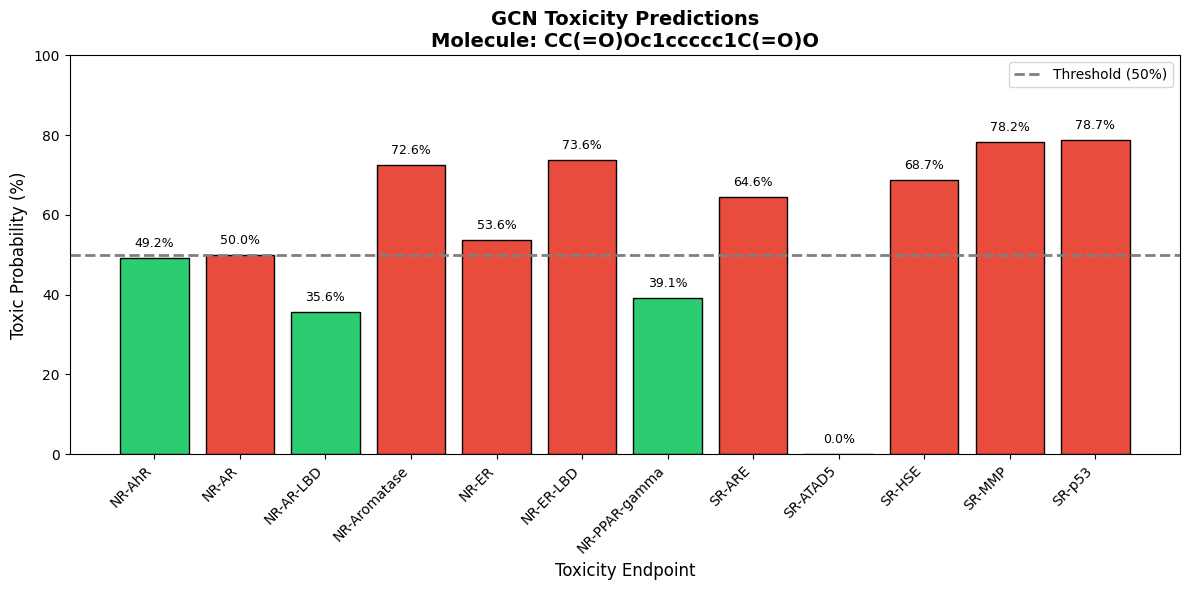

In [36]:

if validation['valid'] and len(all_results) > 0:
    import matplotlib.pyplot as plt
    
    # Get successful predictions
    success_df = results_df[results_df['status'] == 'success'].copy()
    
    if len(success_df) > 0:
        fig, ax = plt.subplots(figsize=(12, 6))
        
        endpoints = success_df['endpoint'].tolist()
        probabilities = success_df['probability'].tolist()
        
        # Color based on probability
        colors = ['#e74c3c' if p > 50 else '#2ecc71' for p in probabilities]
        
        bars = ax.bar(endpoints, probabilities, color=colors, edgecolor='black', linewidth=1)
        
        # Add threshold line
        ax.axhline(y=50, color='gray', linestyle='--', linewidth=2, label='Threshold (50%)')
        
        # Labels and title
        ax.set_xlabel('Toxicity Endpoint', fontsize=12)
        ax.set_ylabel('Toxic Probability (%)', fontsize=12)
        ax.set_title(f'GCN Toxicity Predictions\nMolecule: {validation["canonical_smiles"]}', 
                     fontsize=14, fontweight='bold')
        ax.set_ylim(0, 100)
        
        # Rotate x-axis labels
        plt.xticks(rotation=45, ha='right')
        
        # Add value labels on bars
        for bar, prob in zip(bars, probabilities):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                   f'{prob:.1f}%', ha='center', va='bottom', fontsize=9)
        
        ax.legend()
        plt.tight_layout()
        plt.show()
else:
    print("⚠️ No results to visualize.")

## 💾 Save Results

Save the GCN prediction results to a CSV file.

In [ ]:


if validation['valid'] and len(all_results) > 0:
    from datetime import datetime
    from pathlib import Path
    
    # Create output directory
    output_dir = Path('../results/predictions')
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # Generate filename with timestamp
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    smiles_hash = abs(hash(USER_SMILES)) % 10000
    output_file = output_dir / f'gcn_prediction_{timestamp}_{smiles_hash}.csv'
    
    # Add SMILES to results
    save_df = results_df.copy()
    save_df['smiles'] = validation['canonical_smiles']
    save_df['molecular_weight'] = validation['molecular_weight']
    
    # Save
    save_df.to_csv(output_file, index=False)
    
    print(f"✓ Results saved to: {output_file}")
    print(f"\nSaved data:")
    print(f"  - SMILES: {validation['canonical_smiles']}")
    print(f"  - Molecular Weight: {validation['molecular_weight']} g/mol")
    print(f"  - Endpoints: {len(results_df)}")
else:
    print("⚠️ No results to save.")

✓ Results saved to: ..\results\predictions\gcn_prediction_20251202_211406_3303.csv

Saved data:
  - SMILES: CC(=O)Oc1ccccc1C(=O)O
  - Molecular Weight: 180.16 g/mol
  - Endpoints: 12
